In [1]:
!pip install -q --upgrade --force-reinstall numpy
!pip install -q --upgrade --force-reinstall pandas
!pip install -q --upgrade --force-reinstall --no-deps rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 83.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.5.2 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 16.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.5 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.5.2 which is incompatible.


In [1]:
import numpy as np
print("numpy:", np.__version__)
import rdkit
print("RDKit OK:", rdkit.__version__)
import pandas as pd
print("pandas OK:", pd.__version__)

numpy: 2.5.2
RDKit OK: 2026.03.5
pandas OK: 3.0.5


In [2]:
from google.colab import drive
drive.mount('/content/drive')
SAVE_DIR = '/content/drive/MyDrive/herg_hackathon'

Mounted at /content/drive


In [3]:
import numpy as np
import pandas as pd
from rdkit import DataStructs
from rdkit.DataStructs import ExplicitBitVect

fp_matrix = np.load(f"{SAVE_DIR}/fp_matrix.npy")
meta = pd.read_csv(f"{SAVE_DIR}/herg_featurized_meta.csv")

train_mask = (meta["split"] == "train").values
test_mask = (meta["split"] == "test").values

fp_train = fp_matrix[train_mask]
fp_test = fp_matrix[test_mask]
test_meta = meta[test_mask].reset_index(drop=True)

def to_bitvect(arr):
    bv = ExplicitBitVect(len(arr))
    on_bits = np.where(arr == 1)[0].tolist()
    bv.SetBitsFromList(on_bits)
    return bv

print("Converting fingerprints to bit vectors...")
train_bvs = [to_bitvect(fp) for fp in fp_train]

print(f"Computing nearest-neighbor similarity for {len(fp_test)} test compounds...")
max_similarities = []
for i, test_fp in enumerate(fp_test):
    test_bv = to_bitvect(test_fp)
    sims = DataStructs.BulkTanimotoSimilarity(test_bv, train_bvs)
    max_similarities.append(max(sims))
    if i % 500 == 0:
        print(f"  {i}/{len(fp_test)}")

max_similarities = np.array(max_similarities)
print("Done.")

test_meta["max_train_similarity"] = max_similarities
AD_THRESHOLD = 0.4
test_meta["in_applicability_domain"] = test_meta["max_train_similarity"] >= AD_THRESHOLD

print(f"\nMean nearest-neighbor similarity: {max_similarities.mean():.3f}")
print(f"In AD (sim >= {AD_THRESHOLD}): {test_meta['in_applicability_domain'].sum()} / {len(test_meta)}")
print(f"Out of AD: {(~test_meta['in_applicability_domain']).sum()}")

test_meta.to_csv(f"{SAVE_DIR}/test_with_AD_scores.csv", index=False)
print("\nSaved test_with_AD_scores.csv")

Converting fingerprints to bit vectors...
Computing nearest-neighbor similarity for 3293 test compounds...
  0/3293
  500/3293
  1000/3293
  1500/3293
  2000/3293
  2500/3293
  3000/3293
Done.

Mean nearest-neighbor similarity: 0.661
In AD (sim >= 0.4): 2943 / 3293
Out of AD: 350

Saved test_with_AD_scores.csv


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.9.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.9.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


APPLICABILITY DOMAIN VALIDATION
In-domain compounds  (n=2943):  Accuracy=0.7903, ROC-AUC=0.8759
Out-of-domain compounds (n=350): Accuracy=0.6600, ROC-AUC=0.7361

Accuracy drop for out-of-domain: 0.1303


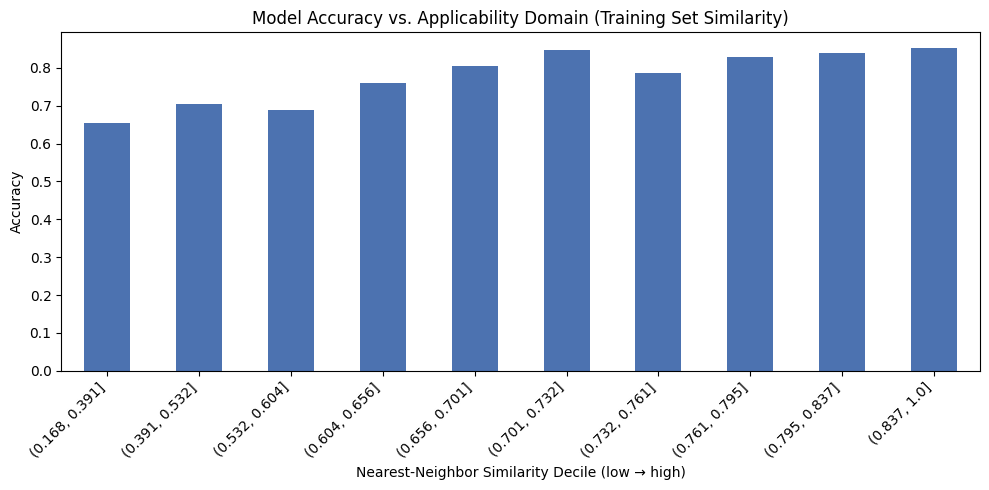


Saved AD_accuracy_by_similarity.png


In [4]:
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import accuracy_score, roc_auc_score
import matplotlib.pyplot as plt

SAVE_DIR = '/content/drive/MyDrive/herg_hackathon'

# Load AD scores and model predictions
test_meta = pd.read_csv(f"{SAVE_DIR}/test_with_AD_scores.csv")
rf = joblib.load(f"{SAVE_DIR}/model_rf_classifier.pkl")

fp_matrix = np.load(f"{SAVE_DIR}/fp_matrix.npy")
meta = pd.read_csv(f"{SAVE_DIR}/herg_featurized_meta.csv")
desc = pd.read_csv(f"{SAVE_DIR}/descriptors.csv")

X = np.hstack([fp_matrix, desc.values])
test_mask = (meta["split"] == "test").values
X_test = X[test_mask]

probs = rf.predict_proba(X_test)[:, 1]
preds = rf.predict(X_test)
y_true = test_meta["label"].values

test_meta["pred"] = preds
test_meta["prob"] = probs
test_meta["correct"] = (test_meta["pred"] == test_meta["label"]).astype(int)

# Compare accuracy: in-domain vs out-of-domain
in_domain = test_meta[test_meta["in_applicability_domain"]]
out_domain = test_meta[~test_meta["in_applicability_domain"]]

acc_in = accuracy_score(in_domain["label"], in_domain["pred"])
acc_out = accuracy_score(out_domain["label"], out_domain["pred"])

auc_in = roc_auc_score(in_domain["label"], in_domain["prob"])
auc_out = roc_auc_score(out_domain["label"], out_domain["prob"])

print("=" * 50)
print("APPLICABILITY DOMAIN VALIDATION")
print("=" * 50)
print(f"In-domain compounds  (n={len(in_domain)}):  Accuracy={acc_in:.4f}, ROC-AUC={auc_in:.4f}")
print(f"Out-of-domain compounds (n={len(out_domain)}): Accuracy={acc_out:.4f}, ROC-AUC={auc_out:.4f}")
print(f"\nAccuracy drop for out-of-domain: {(acc_in - acc_out):.4f}")

# Binned accuracy by similarity decile - shows the trend clearly
test_meta["sim_bin"] = pd.qcut(test_meta["max_train_similarity"], 10, duplicates='drop')
binned_acc = test_meta.groupby("sim_bin")["correct"].mean()

plt.figure(figsize=(10, 5))
binned_acc.plot(kind='bar', color='#4C72B0')
plt.ylabel("Accuracy")
plt.xlabel("Nearest-Neighbor Similarity Decile (low → high)")
plt.title("Model Accuracy vs. Applicability Domain (Training Set Similarity)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/AD_accuracy_by_similarity.png", dpi=150)
plt.show()
print("\nSaved AD_accuracy_by_similarity.png")

test_meta.to_csv(f"{SAVE_DIR}/test_with_AD_scores.csv", index=False)

In [5]:
import pandas as pd
import numpy as np

SAVE_DIR = '/content/drive/MyDrive/herg_hackathon'

submission = pd.read_csv(f"{SAVE_DIR}/submission.csv")
test_meta = pd.read_csv(f"{SAVE_DIR}/test_with_AD_scores.csv")

# Merge AD info into submission
merged = submission.merge(
    test_meta[["compound_id", "max_train_similarity", "in_applicability_domain"]],
    on="compound_id", how="left"
)
merged = merged.rename(columns={
    "max_train_similarity": "AD_similarity_score",
    "in_applicability_domain": "high_confidence"
})

merged.to_csv(f"{SAVE_DIR}/submission.csv", index=False)
print(f"Updated submission.csv with {len(merged)} rows")
print(merged.head(10))

Updated submission.csv with 3293 rows
  compound_id  hERG_blocker_probability  predicted_pIC50  AD_similarity_score  \
0  CMPD_00004                    0.7700             5.65             0.673077   
1  CMPD_00006                    0.5062             5.06             0.434783   
2  CMPD_00016                    0.6200             4.94             0.468085   
3  CMPD_00025                    0.9400             5.52             0.824324   
4  CMPD_00030                    0.4082             4.82             0.363636   
5  CMPD_00033                    0.3367             4.81             0.263158   
6  CMPD_00034                    0.3117             4.81             0.265823   
7  CMPD_00038                    0.4342             4.88             0.270833   
8  CMPD_00042                    0.5944             5.20             0.325000   
9  CMPD_00043                    0.3850             4.05             0.318182   

   high_confidence  
0             True  
1             True  
2      

In [6]:
import pandas as pd

SAVE_DIR = '/content/drive/MyDrive/herg_hackathon'
raw = pd.read_csv(f"{SAVE_DIR}/raw_chembl_herg.csv")

print("Unique assay descriptions containing 'mutant' or variant-related keywords:")
mask = raw['assay_description'].str.contains('mutant|variant|Y652|F656|S624|N588|mutation', case=False, na=False)
print(f"Records matching variant keywords: {mask.sum()} / {len(raw)}")
if mask.sum() > 0:
    print("\nSample matching assay descriptions:")
    print(raw[mask]['assay_description'].drop_duplicates().head(10).to_string())
else:
    print("\nNo variant-specific assays found in this pull — data represents wild-type hERG (CHEMBL240) predominantly.")

Unique assay descriptions containing 'mutant' or variant-related keywords:
Records matching variant keywords: 27 / 20073

Sample matching assay descriptions:
2318    Inhibition of human ERG Y652A mutant expressed...
2319    Inhibition of human ERG F656A mutant expressed...
2326    Inhibition of human ERG S624A mutant expressed...
4960    Inhibition of human ERG Y652A mutant channel e...
4961    Inhibition of human ERG F656A mutant channel e...
4966    Inhibition of human ERG Y652A mutant channel e...
7592    Binding affinity to human ERG F656A tetrameric...
7594    Binding affinity to human ERG F656A tandem dim...
7596    Binding affinity to human ERG S624A tetrameric...
7598    Binding affinity to human ERG Y652A tetrameric...


In [7]:
import pandas as pd

SAVE_DIR = '/content/drive/MyDrive/herg_hackathon'
raw = pd.read_csv(f"{SAVE_DIR}/raw_chembl_herg.csv")

mask = raw['assay_description'].str.contains('Y652A|F656A|S624A|N588K', case=False, na=False)
variant_df = raw[mask].copy()

# Tag which variant each record belongs to
def tag_variant(desc):
    if 'Y652A' in desc: return 'Y652A'
    if 'F656A' in desc: return 'F656A'
    if 'S624A' in desc: return 'S624A'
    if 'N588K' in desc: return 'N588K'
    return 'unknown'

variant_df['hERG_variant'] = variant_df['assay_description'].apply(tag_variant)

print("hERG variant breakdown in dataset:")
print(variant_df['hERG_variant'].value_counts())
print(f"\nTotal variant-specific compounds: {variant_df['chembl_id'].nunique()} unique compounds")
print(f"Total variant-specific records: {len(variant_df)}")

variant_df.to_csv(f"{SAVE_DIR}/herg_variant_subset.csv", index=False)
print("\nSaved herg_variant_subset.csv")

hERG variant breakdown in dataset:
hERG_variant
Y652A    12
F656A    10
S624A     5
Name: count, dtype: int64

Total variant-specific compounds: 8 unique compounds
Total variant-specific records: 27

Saved herg_variant_subset.csv
